In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import numpy as np 

Z = np.load('latent_vectors.npy')
Z_scaled = StandardScaler().fit_transform(Z)

K_range = range(5,21)
inertias = []
silhouettes = []
db_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=15) 
    labels = km.fit_predict(Z_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Z_scaled, labels, sample_size=2000, random_state=42))
    db_scores.append(davies_bouldin_score(Z_scaled, labels))

    print(f"K={k:2d} | Inertia: {km.inertia_:,.1f} | Silhouette: {silhouettes[-1]:.4f} | DB: {db_scores[-1]:.4f}")

K= 5 | Inertia: 66,191.2 | Silhouette: 0.2844 | DB: 1.0857
K= 6 | Inertia: 58,244.1 | Silhouette: 0.2851 | DB: 1.0215
K= 7 | Inertia: 50,994.6 | Silhouette: 0.2748 | DB: 1.0731
K= 8 | Inertia: 47,735.7 | Silhouette: 0.2205 | DB: 1.2562
K= 9 | Inertia: 44,597.1 | Silhouette: 0.2208 | DB: 1.1710
K=10 | Inertia: 42,434.5 | Silhouette: 0.2120 | DB: 1.2990
K=11 | Inertia: 40,302.6 | Silhouette: 0.2200 | DB: 1.2666
K=12 | Inertia: 38,405.2 | Silhouette: 0.2063 | DB: 1.3083
K=13 | Inertia: 36,797.2 | Silhouette: 0.2008 | DB: 1.3088
K=14 | Inertia: 35,529.6 | Silhouette: 0.2014 | DB: 1.2842
K=15 | Inertia: 34,413.4 | Silhouette: 0.1911 | DB: 1.3368
K=16 | Inertia: 33,484.6 | Silhouette: 0.1819 | DB: 1.3919
K=17 | Inertia: 32,567.2 | Silhouette: 0.1842 | DB: 1.3938
K=18 | Inertia: 31,837.5 | Silhouette: 0.1784 | DB: 1.4059
K=19 | Inertia: 30,944.6 | Silhouette: 0.1915 | DB: 1.4120
K=20 | Inertia: 30,184.8 | Silhouette: 0.1858 | DB: 1.4151


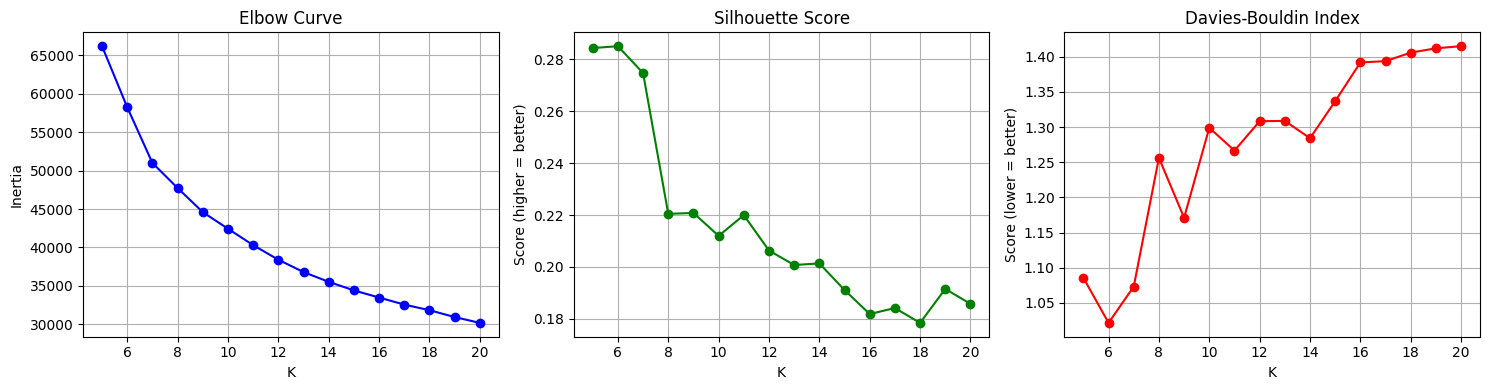

In [ ]:
# Plotting all three metric outputs
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

axes[1].plot(K_range, silhouettes, 'go-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score (higher = better)')
axes[1].grid(True)

axes[2].plot(K_range, db_scores, 'ro-')
axes[2].set_title('Davies-Bouldin Index')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Score (lower = better)')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('k_selection.png', dpi=150)
plt.show()

***Graph Interpretation***
1. Elbow curve: 
    The most noticeable bend (the elbow) occurs around $K=6$ or $K=7$. Beyond this point, increasing $K$ yields diminishing returns in reducing inertia
2. Silhouette score: 
    The highest scores are at $K=5$ and $K=6$ (both $\approx 0.285$). There is a sharp drop-off at $K=8$, suggesting that forcing the data into more than 7 clusters significantly degrades the separation and cohesion of the groups.
3. Davies-Bouldin Index:
    After $K=6$, the index trends upward, indicating that clusters are becoming either more overlapped or less compact. The spike at $K=10$ and the general climb toward $K=20$ confirm that higher $K$ values are inappropriate for this latent space.


While $K=5$ performs well on the Silhouette Score, $K=6$ is the statistically superior choice because: It is the global minimum for the Davies-Bouldin Index and it maintains the highest Silhouette Score alongside $K=5$, and it also sits right at the primary "bend" of the Elbow Curve.

In [6]:
# Manual check of K
import pandas as pd

data = pd.read_csv('reviews_preprocessed.csv')

k_chosen = 6
km_final = KMeans(n_clusters=k_chosen, random_state=42, n_init=15)
labels_init = km_final.fit_predict(Z_scaled)

print("==== CLUSTER SAMPLE REVIEW ====\n")

for cluster_id in range(k_chosen):
    cluster_mask = labels_init == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    sample = np.random.choice(cluster_indices, min(5, len(cluster_indices)), replace=False)

    print(f"--- Cluster {cluster_id} ({cluster_mask.sum()} reviews) ---")
    for idx in sample:
        print(f"  [{data['score'].iloc[idx]}] - {data['content_clean'].iloc[idx][:120]}")
    print()


==== CLUSTER SAMPLE REVIEW ====

--- Cluster 0 (2178 reviews) ---
  [3] - i love it but the app keeps crashing when i try to invite friends to party and i can't buy gems
  [3] - no doubt this app is amazing and this app deserve 5 star but i am frustrated because this app doesn't keep log more than
  [5] - helps me turn my crippling depression into regular depression
  [5] - nice application it was really very useful i did my work on time i was so much free time so that's good news i love it i
  [3] - seemed like a good app but doesn't always show your plans it's linked to my calender and i've added quite a few things f

--- Cluster 1 (1568 reviews) ---
  [3] - this app doesnt require your firstborn in order to function as similar apps do the quick post function is great however 
  [5] - my chaotic life revolves around my schedule this app is perfect for organizing the choas
  [5] - great app helps plan my day and give me foresight into what's coming up
  [5] - one of my biggest problem

In [8]:
# Saving centroids

km_unscaled = KMeans(n_clusters=k_chosen, random_state=42, n_init=15)
km_unscaled.fit(Z)

initial_centroids = km_unscaled.cluster_centers_
print(f"Centroids shape: {initial_centroids.shape}")

np.save('initial_centroids.npy', initial_centroids)
np.save('kmeans_init_labels.npy', km_unscaled.labels_)
print("Centroids saved.")

Centroids shape: (6, 32)
Centroids saved.


- Cluster 2 (240 reviews) -- Very tight
Premium/payment + sync failure + customer support. "Paid for premium but it doesn't work and customer service won't respond", that's a coherent, specific pain point. Best cluster in the set.
- Cluster 3 (808 reviews) -- Tight
Widgets and notifications broken after updates. Alarms not firing, widget reverting, notification issues on specific devices. Clear technical bug theme.
- Cluster 5 (532 reviews) -- Good
Login issues, pricing transparency complaints, poor customer support, sync problems for paid users. Slightly overlaps with Cluster 2 on the support/sync axis but the entry point is different — Cluster 2 is "I paid and it broke", Cluster 5 is "I can't even get in / didn't know it cost money".
- Cluster 1 (1568 reviews) -- Loose but acceptable
General positive reviews about productivity and scheduling. The variance is high because "good app" reviews don't have a specific topic, they're just satisfied users. Expected outcome for DEC.
- Cluster 4 (2498 reviews) -- Too broad
This is your problem cluster. It contains widget complaints, Google Calendar comparisons, notification issues, general negative reviews, and design feedback all mixed together. 2,498 reviews is 32% of the dataset in one cluster. The joint training should break this up as the clustering loss forces tighter separation.
- Cluster 0 (2178 reviews) -- Also broad
Mix of crash reports, positive reviews, and general feedback.